<div>
<img src="https://www.cosmos.esa.int/documents/3414525/0/Logo_Gaia_may_23_2022.png/cf6be61e-609e-27dc-3ad6-03ac5209bdc4?t=1653299950248" width="300" align="right"/>
</div>


# Tutorial:  Retrieve the BP/RP (XP) spectra associated to a sample of candidate Pleiades stars

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


---
Copyright (c) European Space Agency, 2025.

This file is subject to the terms and conditions defined in file **[LICENSE.txt](LICENSE.txt)**, which
is part of this source code package. No part of the package, including
this file, may be copied, modified, propagated, or distributed except according to
the terms contained in the file **[LICENSE.txt](LICENSE.txt)**.

---




**Release number:** 
v1.2 (2025-05-30)


**Applicable Gaia Data Releases:**
Gaia EDR3, Gaia DR3


**Summary:** 

This code shows how to retrieve the different DataLink products associated to a sample of stars associated to the Pleiades open cluster.



**Useful URLs:**

* [Questions or suggestions](https://www.cosmos.esa.int/web/gaia/questions)
* [Tutorials, documentation, and more](https://www.cosmos.esa.int/web/gaia-users/archive)
* [Known issues in the Gaia data](https://www.cosmos.esa.int/web/gaia-users/known-issues)
* [Gaia data credits and acknowledgements](https://www.cosmos.esa.int/web/gaia-users/credits)
* [PyESASky](https://www.cosmos.esa.int/web/esdc/pyesasky)
* [PyESASky - ESDC Git](https://github.com/esdc-esac-esa-int/pyesasky)

In [1]:
from astropy.table import Table
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt
from pyesasky import ESASkyWidget
from pyesasky.models import Catalogue, MetadataType
from pyesasky.descriptors import CatalogueDescriptor, MetadataDescriptor

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Important: Gaia archive will be intermittently unavailable due to scheduled maintenance (deployment of a new version) on Wednesday 4th from 11h to 12h


In [2]:
def make_canvas(title = '', xlabel = '', ylabel = '', show_grid = False, show_legend = False, fontsize = 12):
    ""
    "Generic function to simplify the editing of plots"
    ""
    plt.title(title,    fontsize = fontsize)
    plt.xlabel(xlabel,  fontsize = fontsize)
    plt.ylabel(ylabel , fontsize = fontsize)
    plt.xticks(fontsize = fontsize)
    plt.yticks(fontsize = fontsize)
    if show_grid:
        plt.grid()
    if show_legend:
        plt.legend(fontsize = fontsize)


def esasky_oplot(inp_cat, catalogueName = 'my_cat', color = 'red', lineWidth = 2):
    ""
    "ESASky catalogue plotter"
    ""
    catalogue = Catalogue(catalogueName, 'J2000', color, lineWidth)
    for i in range(len(inp_cat)):
        catalogue.add_source(inp_cat['source_id'][i], inp_cat['ra'][i], inp_cat['dec'][i], i + 1, [], [])
    esasky.overlay_cat(catalogue)
    
    
def plot_sampled_spec(inp_table, color = 'blue', title = '', fontsize = 16, show_legend = True, show_grid = True, linewidth = 2, legend = '', figsize = [25,7], show_plot = True):
    ""
    "RVS & XP sampled spectrum plotter. 'inp_table' MUST be an Astropy-table object."
    ""
    if show_plot:
        fig      = plt.figure(figsize=figsize)
    xlabel   = f'Wavelength [{inp_table["wavelength"].unit}]'
    ylabel   = f'Flux [{inp_table["flux"].unit}]'
    plt.plot(inp_table['wavelength'], inp_table['flux'], '-', linewidth = linewidth, label = legend)
    make_canvas(title = title, xlabel = xlabel, ylabel = ylabel, fontsize= fontsize, show_legend=show_legend, show_grid = show_grid)
    if show_plot:
        plt.show()

##  Download data sample

The query below retrieves a 1-degree cone-search centred in Alcyone (brightest star of the Pleiades open cluster)

In [3]:
radius  = 1.0        # Degrees
inp_ra  = 56.87125   # Degrees
inp_dec = 24.10493   # Degrees

In [4]:
query = f"SELECT * FROM gaiadr3.gaia_source_lite \
WHERE 1=CONTAINS(POINT({inp_ra}, {inp_dec}),CIRCLE(ra, dec, {radius})) AND \
ruwe <1.4 AND parallax_over_error >10"

job     = Gaia.launch_job_async(query)
results = job.get_results()
print(f'Table size (rows): {len(results)}')
results['source_id', 'ra', 'dec', 'pmra' ,'pmdec', 'parallax']

INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 4032


source_id,ra,dec,pmra,pmdec,parallax
,deg,deg,mas / yr,mas / yr,mas
int64,float64,float64,float64,float64,float64
69805798521250560,56.24863115999279,24.642582257680882,2.190487348950862,-13.465314592937117,0.9437596679009509
69805901600465152,56.24727995894163,24.65570538537785,0.49759409475044836,-3.8273885658895668,0.8311574217226121
69805901600465536,56.248963878828214,24.646361688721974,7.372404958972663,-6.369812663837182,1.5491388879533554
69805935960203392,56.27054240577331,24.6474754189256,6.8928967344856975,-8.05494305625505,1.025008949947923
69806039039416832,56.27740714247925,24.678409040272616,20.24411977407674,-44.80748682496666,7.5284014269211195
69806107758894976,56.24396966595952,24.665878429795082,30.429650578356245,-21.351212463789484,2.9152954059140637
69806107758895104,56.241044070606705,24.664036267040704,7.383219341257357,-1.4144879294953903,1.0237043621074358
69806142118633984,56.21224469443437,24.666776076898838,-2.299934195324371,-7.141252554177461,0.849064870039556


### Inspect results

Pleiades candidate sources are selected by filtering a circular area (radius = 3 mas/yr) around the Pleiades proper motion distribution (centre at ~ [20,-50] mas/yr in [pmra, pmdec])

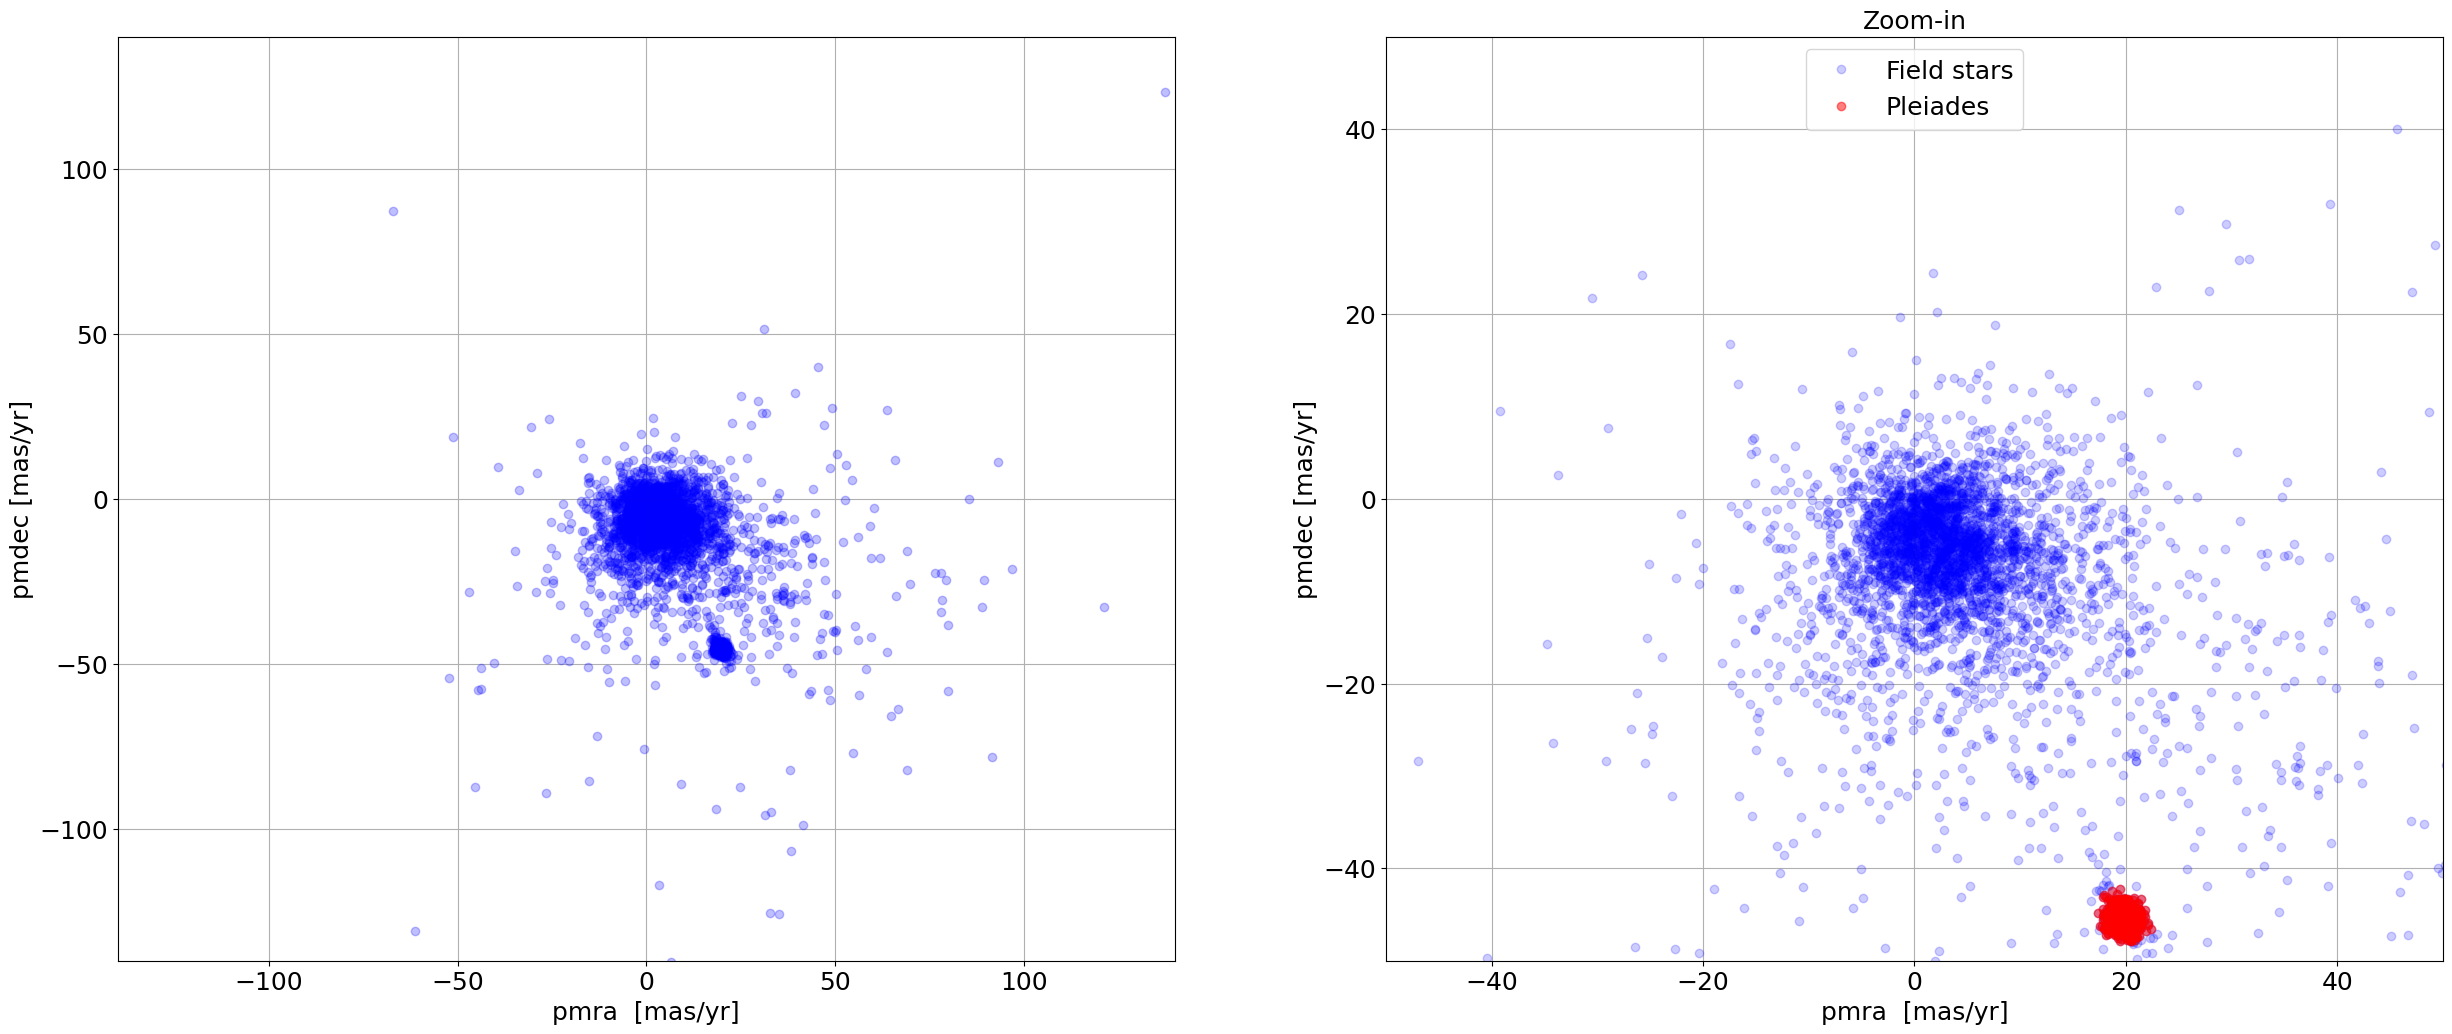

In [5]:
# Identify Pleiades candidate members =======
radius_pm = 3   # Radius applied to select Pleiades sample in the PMRA-PMDEC space
pmra_c    = 20  # Approx. centre of the Pleiades Cluster pmra.
pmdec_c   = -45 # Approx. centre of the Pleiades Cluster pmdec.
els       = np.sqrt((results['pmra']-pmra_c)**2 + (results['pmdec']-pmdec_c)**2) <radius_pm # Selected Pleiades sample
pl_samp   = results[els]



# Plot & Zoom ===============================
fig       = plt.figure(figsize=[30,12])
fontsize  = 18

# Panel 1 ===============
plt.subplot(121)
plt.plot(results['pmra'], results['pmdec'], 'bo', alpha = 0.25)
make_canvas(xlabel='pmra  [mas/yr]',ylabel='pmdec [mas/yr]', fontsize = fontsize, show_grid = True)
z_fac = 140   # Zoom-in factor
plt.xlim([-z_fac,z_fac])
plt.ylim([-z_fac,z_fac])


# Panel 2 ===============
plt.subplot(122)
plt.plot(results['pmra'], results['pmdec'], 'bo', alpha = 0.20, label = 'Field stars')
plt.plot(pl_samp['pmra'], pl_samp['pmdec'], 'ro', alpha = 0.50, label = 'Pleiades')
z_fac = 50   # Zoom-in factor
plt.xlim([-z_fac,z_fac])
plt.ylim([-z_fac,z_fac])


make_canvas(title = 'Zoom-in', xlabel='pmra  [mas/yr]',ylabel='pmdec [mas/yr]', fontsize = fontsize, show_grid = True, show_legend = True)
plt.show()

## Show results in ESASky

In [6]:
esasky = ESASkyWidget()
esasky

Box(children=(VBox(children=(FileChooser(path='/Users/hcanovas/Library/CloudStorage/OneDrive-ESA/job/gaia_sco9…

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<IPython.core.display.HTML object>', '…

ESASkyWidget(layout=Layout(align_self='stretch', height='400px'))

In [7]:
# Plot Cone Search in ESASky =================
esasky_oplot(results, catalogueName = 'Pleiades Cone Search', color = 'blue')
esasky.set_fov(radius*2.5)
esasky.go_to(results['ra'].mean(), results['dec'].mean())
esasky_oplot(pl_samp, catalogueName = 'Pleiades selected', color = 'red')

### Show different sub-samples in ESASky

In [8]:
esasky_oplot(pl_samp[pl_samp['has_xp_sampled'] == True],    catalogueName = 'Pleiades XP Sampled',    color = 'white')
esasky_oplot(pl_samp[pl_samp['has_xp_continuous'] == True], catalogueName = 'Pleiades XP Continuous', color = 'green')

# esasky_oplot(pl_samp[pl_samp['has_epoch_photometry'] == True], catalogueName = 'Pleiades Epoch Phot', color = 'white')
# esasky_oplot(pl_samp[pl_samp['has_rvs'] == True],              catalogueName = 'Pleiades RVS',        color = 'green')

## Download the DataLink Products associated to the selected (Pleiades) sample

DataLink products are labelled as: ```"<retrieval_type>-<data release> <source_id>.<format>"```, where:
* retrieval_type = 'EPOCH_PHOTOMETRY', 'MCMC_GSPPHOT', 'MCMC_MSC', 'XP_SAMPLED', 'XP_CONTINUOUS', 'RVS', 'ALL'
* data_structure = 'INDIVIDUAL', 'COMBINED', 'RAW'

For more information about DataLink products please read the tutorials in this [Section](https://www.cosmos.esa.int/web/gaia-users/archive/datalink-products).

### XP Sampled spectra

The first line in the code below selects the sources in the "Pleiades sample" that contain XP sampled products and then retrieves these products.

In [9]:
inp_samp       = pl_samp[pl_samp['has_xp_sampled'] == True]
retrieval_type = 'XP_SAMPLED'
data_structure = 'INDIVIDUAL'
# dl_key         = 'XP_SAMPLED_COMBINED.xml'  # With Python f-strings: dl_key = f'{retrieval_type}_{data_structure}.xml'


datalink    = Gaia.load_data(ids=inp_samp['source_id'], retrieval_type=retrieval_type, data_structure = data_structure) 

print(f"* {len(datalink)} XP sampled spectra have been downloaded - they are stored inside the 'datalink' Python dictionary")

* 120 XP sampled spectra have been downloaded - they are stored inside the 'datalink' Python dictionary


The ```datalink``` instance retrieved above consists of a Python dictionary that contains 120 individual spectra. Each of these contain data and metadata. The code below shows how to access to these individual spectra.

In [10]:
# Inspect the dictionary content (only listing its first 3 elements)
dl_keys = list(datalink.keys())
dl_keys[0:3]

['XP_SAMPLED-Gaia DR3 66745617143891968.xml',
 'XP_SAMPLED-Gaia DR3 66832100605159424.xml',
 'XP_SAMPLED-Gaia DR3 64979732749686016.xml']

Listing XP spectra for: Gaia DR3 66745617143891968


wavelength,flux,flux_error
nm,W / (nm m2),W / (nm m2)
float64,float32,float32
336.0,1.0992322e-13,1.0550125e-14
338.0,1.09431405e-13,8.976246e-15
340.0,9.8037694e-14,8.3271606e-15
342.0,8.3391464e-14,8.0938996e-15
344.0,7.8887736e-14,8.333658e-15


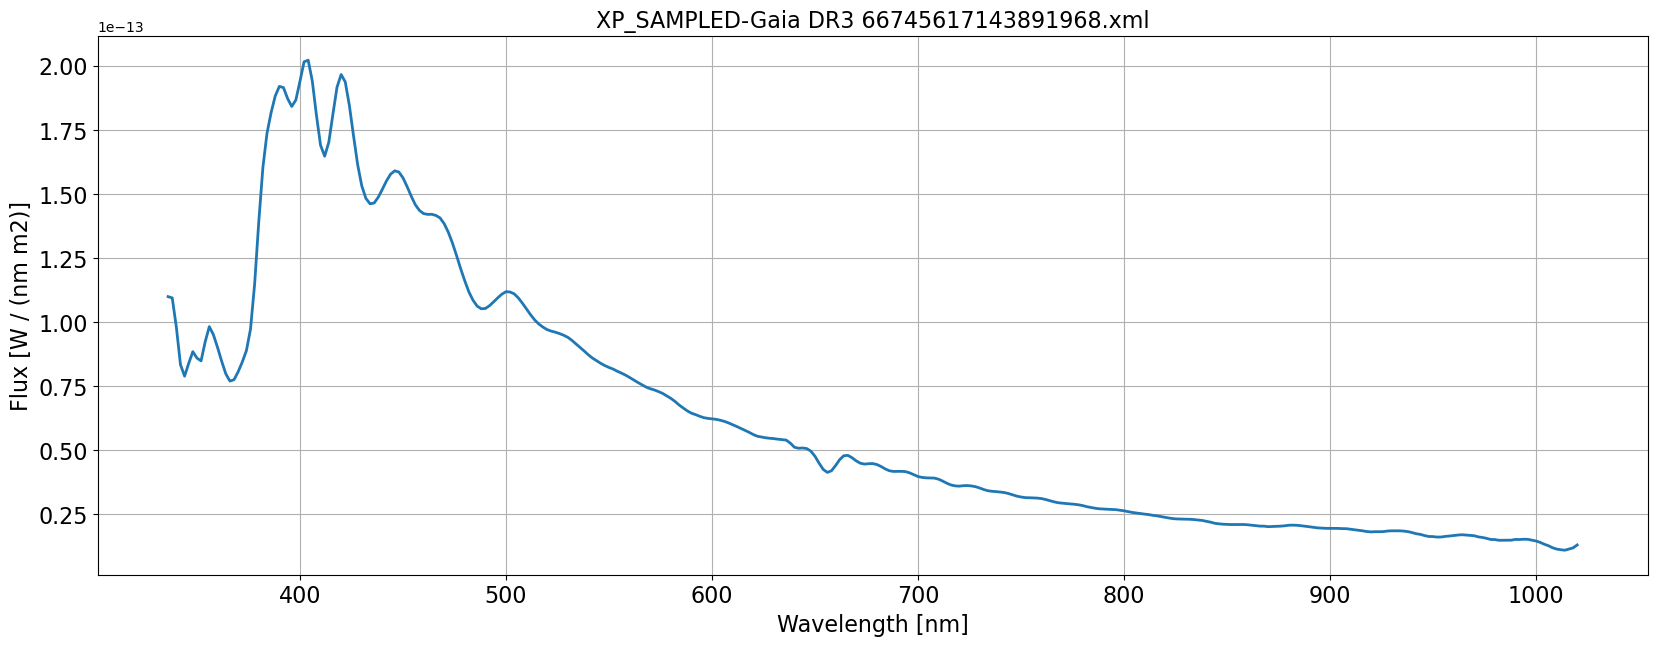

In [11]:
ii = 0

inp_key    = dl_keys[ii]
votable    = datalink[inp_key][0]
source_id  = votable.get_field_by_id_or_name('source_id').value
inp_table  = votable.to_table()
print(f"Listing XP spectra for: Gaia DR3 {source_id}")
display(inp_table[0:5])

plot_sampled_spec(inp_table, title=dl_keys[ii], legend = '', show_plot=True, figsize=[20,7], show_legend=False)

In [12]:
# Inspect full metadata content:
for item in votable.iter_fields_and_params():
    print(item)

<PARAM ID="source_id" datatype="long" name="source_id" ucd="meta.id;meta.main" value="66745617143891968"/>
<PARAM ID="solution_id" datatype="long" name="solution_id" ucd="meta.version" value="4545469030156206080"/>
<PARAM ID="spatialLocation" arraysize="2" datatype="double" name="spatialLocation" ucd="pos.eq" unit="deg" utype="spec:Char.SpatialAxis.Coverage.Location.Value" value="[57.34071662 24.38075239]"/>
<PARAM ID="TimeAxisCoverageLocation" datatype="double" name="TimeAxisCoverageLocation" ucd="time.epoch" unit="yr" utype="spec:Char.TimeAxis.Coverage.Location.Value" value="2016.0"/>
<PARAM ID="TimeAxisCoverageBoundsExtent" datatype="double" name="TimeAxisCoverageBoundsExtent" ucd="time.duration" unit="yr" utype="spec:Char.TimeAxis.Coverage.Bounds.Extent" value="2.83"/>
<PARAM ID="spectralAccuracyStatError" datatype="double" name="spectralAccuracyStatError" ucd="stat.error;em.wl" unit="nm" utype="spec:Char.SpectralAxis.Accuracy.StatError" value="0.0"/>
<PARAM ID="spectralLocation" d